<a href="https://colab.research.google.com/github/harshkumar8a/RAGAS-Implement/blob/main/Ragas_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ragas Implementation

### Importing the important libraries



In [2]:
!pip install ragas langchain langgraph langchain-openai chromadb sentence-transformers datasets chroma pymupdf langchain-huggingface langchain-groq

In [3]:
!sudo apt-get install zstd

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
zstd is already the newest version (1.4.8+dfsg-3build1).
0 upgraded, 0 newly installed, 0 to remove and 132 not upgraded.


In [4]:
!sudo apt update
!sudo apt install -y pciutils
!curl -fsSL https://ollama.com/install.sh | sh

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
132 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as r

In [5]:
import threading
import subprocess
import time

def run_ollama_serve():
  subprocess.Popen(["ollama", "serve"])

thread = threading.Thread(target=run_ollama_serve)
thread.start()
time.sleep(5)

In [6]:
!ollama pull llama3.1:8b

In [7]:
!ollama pull qwen3-embedding:0.6b


In [8]:
!pip install langchain_ollama langchain-chroma

### Import the dependencies

In [25]:
import os
from typing import TypedDict, List

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langgraph.graph import StateGraph, END
from langchain_ollama import OllamaEmbeddings
from langchain_ollama import OllamaLLM
from dotenv import load_dotenv
from IPython.display import Image, display
import pandas as pd
from datasets import Dataset

from ragas import evaluate, RunConfig
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall,
)

from langchain_ollama import OllamaLLM
load_dotenv()

/tmp/ipykernel_5781/956388334.py:17: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import (
/tmp/ipykernel_5781/956388334.py:17: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import (
/tmp/ipykernel_5781/956388334.py:17: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import (
/tmp/ipykernel_5781/956388334.py:17: DeprecationWarning: Importing context_recall from 'ragas.metrics' is deprecated and will be removed

False

###  State schema


In [11]:
class RAGState(TypedDict):
    query: str
    retrieved_chunks: List[Document]
    answer: str

# Sample corpus

  * Here we use the dummy datasets for learning RAGAS metrix

In [12]:
CORPUS = [
    "The transformer architecture relies on self-attention mechanisms that allow "
    "each token to attend to every other token in the sequence.",
    "RAGAS is a framework for evaluating Retrieval-Augmented Generation systems "
    "without requiring human-annotated reference answers for most metrics.",
    "Faithfulness in RAGAS measures whether the generated answer is grounded in "
    "the retrieved context, detecting hallucinated claims.",
    "Context Precision rewards retrievers that surface relevant chunks at the top "
    "of the ranked list, penalising noise in early positions.",
    "Answer Relevance uses reverse question generation: the LLM proposes questions "
    "the answer could address, then measures cosine similarity to the original query.",
    "Vector databases store dense embeddings and support approximate nearest-neighbour "
    "search, forming the backbone of most modern RAG retrievers.",
]

### Implement the OllamaLLM & OllamaEmbeddings model

*   OllamaLLM --> **"llama3.1:8b"**
*   OllamaEmbeddings --> **"qwen3-embedding:0.6b"**



In [13]:
llm = OllamaLLM(model="llama3.1:8b",temperature=0,format="json")
embeddings = OllamaEmbeddings(model="qwen3-embedding:0.6b")


### Build vector store


In [14]:
splitter = RecursiveCharacterTextSplitter(chunk_size=200, chunk_overlap=20)
docs = splitter.create_documents(CORPUS)

vectorstore = Chroma.from_documents(docs, embeddings, collection_name="ragas_demo")
retriever = vectorstore.as_retriever(search_kwargs={"k": 6})

### LangGraph node definitions
*   retrieve_node()
*   generate_node()

In [15]:
def retrieve_node(state: RAGState) -> RAGState:
    """Fetch top-k relevant chunks for the query."""
    chunks = retriever.invoke(state["query"])
    return {**state, "retrieved_chunks": chunks}

def generate_node(state: RAGState) -> RAGState:
    """Synthesise an answer from the retrieved context."""
    context = "\n\n".join(doc.page_content for doc in state["retrieved_chunks"])
    prompt = (
        f"Answer the question using ONLY the context below. "
        f"If the context doesn't contain the answer, say so.\n\n"
        f"Context:\n{context}\n\n"
        f"Question: {state['query']}"
    )
    response = llm.invoke(prompt)
    return {**state, "answer": response}

### Assemble the graph


In [16]:
builder = StateGraph(RAGState)
builder.add_node("retrieve", retrieve_node)
builder.add_node("generate", generate_node)
builder.set_entry_point("retrieve")
builder.add_edge("retrieve", "generate")
builder.add_edge("generate", END)
rag_pipeline = builder.compile()


### Build an evaluation dataset (query + ground truth answer pairs)


In [18]:
eval_queries = [
    {
        "question": "What does the Faithfulness metric measure in RAGAS?",
        "ground_truth": (
            "Faithfulness measures whether the generated answer is entirely "
            "grounded in the retrieved context, detecting hallucinated claims."
        ),
    },
    {
        "question": "How does Answer Relevance work?",
        "ground_truth": (
            "Answer Relevance uses reverse question generation — the LLM proposes "
            "questions the answer could address — then measures cosine similarity "
            "to the original query."
        ),
    },
]

### Run pipeline and capture traces


In [19]:
traces = []
for item in eval_queries:
    result = rag_pipeline.invoke({"query": item["question"]})
    traces.append({
        "question":       item["question"],
        "answer":         result["answer"],
        "contexts":       [doc.page_content for doc in result["retrieved_chunks"]],
        "ground_truth":   item["ground_truth"],
    })

### Build Evaluation Dataset


In [20]:

eval_queries = [
    {
        "question": "What does the Faithfulness metric measure in RAGAS?",
        "ground_truth": (
            "Faithfulness measures whether the generated answer is entirely "
            "grounded in the retrieved context and detects hallucinated claims."
        ),
    },
    {
        "question": "How does Answer Relevance work?",
        "ground_truth": (
            "Answer Relevance uses reverse question generation where the LLM "
            "proposes questions the answer could address and compares them "
            "to the original query using semantic similarity."
        ),
    },
]

### Run RAG Pipeline


In [21]:
traces = []

for item in eval_queries:

    result = rag_pipeline.invoke(
        {
            "query": item["question"]
        }
    )

    traces.append(
        {
            "user_input": item["question"],
            "response": result["answer"],
            "retrieved_contexts": [
                doc.page_content
                for doc in result["retrieved_chunks"]
            ],
            "reference": item["ground_truth"],
        }
    )

### Create HuggingFace Dataset


In [22]:

eval_dataset = Dataset.from_list(traces)

### Ollama Evaluator LLM


In [23]:

ragas_llm = OllamaLLM(
    model="llama3.1:8b",
    temperature=0,
    format="json",
)

### Run RAGAS Evaluation


In [26]:
results = evaluate(
    dataset=eval_dataset,
    metrics=[
        faithfulness,
        answer_relevancy,
        context_precision,
        context_recall,
    ],
    llm=ragas_llm,
    embeddings=embeddings,
    run_config=RunConfig(
        timeout=600,
        max_workers=1,
        max_retries=3,
    ),
)


Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

In [27]:
# Convert Results to DataFrame

df = results.to_pandas()

# Rename columns for readability
df = df.rename(
    columns={
        "user_input": "question",
        "retrieved_contexts": "contexts",
        "response": "answer",
        "reference": "ground_truth",
    }
)

### Display Results


In [28]:
print("\nRAGAS Evaluation Results:\n")

required_cols = [
    "question",
    "faithfulness",
    "answer_relevancy",
    "context_precision",
    "context_recall",
]

available_cols = [
    col
    for col in required_cols
    if col in df.columns
]

print(
    df[available_cols].to_string(index=False)
)


RAGAS Evaluation Results:

                                           question  faithfulness  answer_relevancy  context_precision  context_recall
What does the Faithfulness metric measure in RAGAS?           1.0          0.606242                1.0        1.000000
                    How does Answer Relevance work?           1.0          0.959229                1.0        0.166667


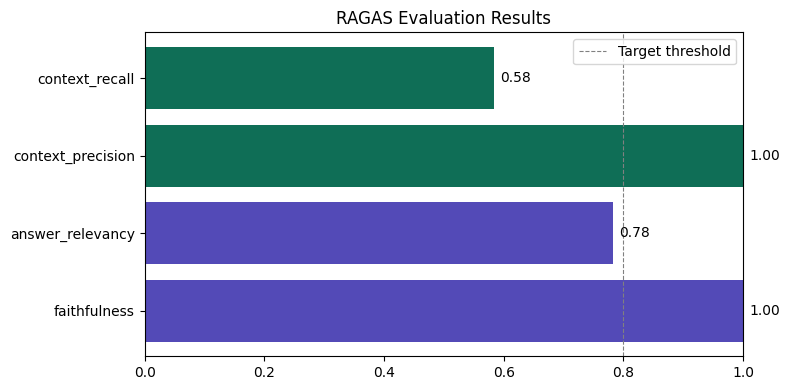

In [29]:
# Plot Metrics

metric_columns = [
    "faithfulness",
    "answer_relevancy",
    "context_precision",
    "context_recall",
]

scores = []

for metric in metric_columns:

    value = df[metric].mean()

    if pd.isna(value):
        value = 0.0

    scores.append(float(value))

try:

    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(8, 4))

    bars = ax.barh(
        metric_columns,
        scores,
        color=[
            "#534AB7",
            "#534AB7",
            "#0F6E56",
            "#0F6E56",
        ],
    )

    ax.set_xlim(0, 1.0)

    ax.axvline(
        0.8,
        color="gray",
        linestyle="--",
        linewidth=0.8,
        label="Target threshold",
    )

    for bar, score in zip(bars, scores):

        ax.text(
            score + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{score:.2f}",
            va="center",
        )

    ax.set_title("RAGAS Evaluation Results")

    ax.legend()

    plt.tight_layout()

    plt.show()

except ModuleNotFoundError:

    print("\nmatplotlib is not installed.")

In [30]:
plt.savefig('metrix.png')

<Figure size 640x480 with 0 Axes>